In [18]:
# ====================================================
# STEP 0: IMPORT LIBRARIES
# ====================================================

# Numerical operations
import numpy as np

# Data handling (CSV file)
import pandas as pd

# Plot graphs
import matplotlib.pyplot as plt

# Data scaling (normalize between 0 and 1)
from sklearn.preprocessing import MinMaxScaler

# Deep Learning model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input

In [19]:
# ====================================================
# STEP 1: UPLOAD DATASET
# ====================================================

# Provide full file path (Windows format → use raw string r'')
file_path = r"C:\Users\lenovo\OneDrive\Pictures\DL-exam\DL_4\Google_Stock_Price.csv"

# Read CSV file
df = pd.read_csv(file_path,thousands=',')

# Show confirmation
print("File loaded successfully!")

# Display first 5 rows
print(df.head())

File loaded successfully!
                       Price    Adj Close        Close         High  \
0                     Ticker        GOOGL        GOOGL        GOOGL   
1                       Date          NaN          NaN          NaN   
2  2020-01-02 00:00:00+00:00  68.18682098  68.43399811  68.43399811   
3  2020-01-03 00:00:00+00:00  67.83010101   68.0759964      68.6875   
4  2020-01-06 00:00:00+00:00  69.63805389  69.89050293  69.91600037   

           Low         Open    Volume  
0        GOOGL        GOOGL     GOOGL  
1          NaN          NaN       NaN  
2  67.32450104  67.42050171  27278000  
3  67.36599731  67.40000153  23408000  
4  67.55000305  67.58149719  46768000  


In [20]:
# ====================================================
# EXTRACT 'OPEN' PRICE COLUMN
# ====================================================

# Convert 'Open' column to numeric
# errors='coerce' → converts invalid values to NaN
# dropna() → removes missing values
# reshape(-1,1) → converts into 2D array (required for ML/DL models)

data = pd.to_numeric(df['Open'], errors='coerce') \
            .dropna() \
            .values.reshape(-1, 1)

# Print shape of processed data
print("Data shape:", data.shape)

Data shape: (1258, 1)


In [21]:
# ====================================================
# STEP 3: DATA NORMALIZATION
# ====================================================

from sklearn.preprocessing import MinMaxScaler

# Create scaler object → scales values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler on data and transform it
data_scaled = scaler.fit_transform(data)

# =========================
# PRINT OUTPUT
# =========================

# Show first 5 scaled values
print("First 5 scaled values:")
print(data_scaled[:5])

# Show shape of data
print("\nShape of scaled data:", data_scaled.shape)

# Show min and max values after scaling
print("\nMin value:", data_scaled.min())
print("Max value:", data_scaled.max())


First 5 scaled values:
[[0.10109984]
 [0.1009579 ]
 [0.10221452]
 [0.11911877]
 [0.11716625]]

Shape of scaled data: (1258, 1)

Min value: 0.0
Max value: 1.0


In [22]:
# ====================================================
# STEP 4: TRAIN-TEST SPLIT
# ====================================================

# Calculate 80% of total data → training size
train_size = int(len(data_scaled) * 0.8)

# First 80% data → training set
train_data = data_scaled[:train_size]

# Remaining 20% data → testing set
test_data = data_scaled[train_size:]


In [23]:
# ====================================================
# STEP 5: CREATE TIME SERIES DATASET
# ====================================================

# Function to convert data into sequences
# Uses last 60 days → to predict next day

def create_dataset(dataset):
    
    X = []   # Input → past 60 days
    y = []   # Output → next day value
    
    # Start from index 60 (because we need 60 previous values)
    for i in range(60, len(dataset)):
        
        # Take previous 60 values as input
        X.append(dataset[i-60:i, 0])
        
        # Take current value as output
        y.append(dataset[i, 0])
    
    # Convert lists → numpy arrays
    return np.array(X), np.array(y)


# Apply function on training and testing data
X_train, y_train = create_dataset(train_data)
X_test, y_test   = create_dataset(test_data)

# =========================
# PRINT OUTPUT
# =========================

# Print shapes
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


# Show one sample
print("\nSample Input (first sequence of 60 values):")
print(X_train[0])

print("\nSample Output (next value):")
print(y_train[0])

X_train shape: (946, 60)
y_train shape: (946,)

X_test shape: (192, 60)
y_test shape: (192,)

Sample Input (first sequence of 60 values):
[0.10109984 0.1009579  0.10221452 0.11911877 0.11716625 0.12655131
 0.12916159 0.1311625  0.1328069  0.13039053 0.1346936  0.1406099
 0.14630809 0.1500227  0.14926801 0.15109238 0.1298782  0.13340925
 0.13919745 0.13214914 0.14245159 0.14030178 0.13782313 0.1409803
 0.13695419 0.1422889  0.14569539 0.15817185 0.15906848 0.15703984
 0.15860807 0.1585423  0.16299422 0.16015897 0.15516349 0.12693904
 0.12969126 0.11722166 0.10481439 0.07544753 0.10213148 0.11815637
 0.10475206 0.10010971 0.07393817 0.05143961 0.06855153 0.06643289
 0.02293475 0.04106445 0.01150718 0.01186376 0.00123589 0.01102598
 0.02580114 0.         0.01648187 0.02361327 0.02019988 0.02461375]

Sample Output (next value):
0.02640351629478216


In [24]:
# ====================================================
# STEP 6: RESHAPE DATA FOR RNN
# ====================================================

# RNN/LSTM requires 3D input:
# (samples, time_steps, features)

# Before reshape → 2D data
print("Before Reshape:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


# Reshape training data → add 1 feature dimension
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

# Reshape testing data → same process
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


# After reshape → 3D data
print("\nAfter Reshape:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


# Show one sample shape
print("\nSingle sample shape:", X_train[0].shape)


Before Reshape:
X_train shape: (946, 60)
X_test shape : (192, 60)

After Reshape:
X_train shape: (946, 60, 1)
X_test shape : (192, 60, 1)

Single sample shape: (60, 1)


In [25]:
# ====================================================
# STEP 7: BUILD RNN MODEL
# ====================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input

# Create Sequential model (layer-by-layer)
model = Sequential()

# Input layer → shape = (time_steps=60, features=1)
model.add(Input(shape=(60, 1)))

# First RNN layer
# 50 neurons → learn patterns
# return_sequences=True → pass sequence to next RNN layer
model.add(SimpleRNN(50, return_sequences=True))

# Second RNN layer
# Final sequence learning (no return_sequences)
model.add(SimpleRNN(50))

# Output layer → predicts next value (single number)
model.add(Dense(1))


# Compile model
model.compile(
    optimizer='adam',              # Optimizer → controls learning
    loss='mean_squared_error'      # Loss → measures prediction error
)

# Display model structure
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ====================================================
# STEP 8: TRAIN MODEL
# ====================================================

# Train the RNN model using training data
history = model.fit(
    X_train,          # Input data (past 60 days)
    y_train,          # Output data (next day price)
    
    epochs=20,        # Number of times model learns from full dataset
    batch_size=32     # Number of samples processed at once
)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 66s 176ms/step - loss: 0.0588
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - loss: 0.0024
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - loss: 8.2044e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - loss: 7.0799e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 6.8656e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 6.4702e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - loss: 5.6491e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 5.7848e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 5.4359e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 5.0498e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 4.6563e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - loss: 4.5450e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - loss: 4.3897e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - loss: 4.5493e-04
Epoch 15/20
30

In [27]:
# ====================================================
# STEP 9: MAKE PREDICTIONS
# ====================================================

# Predict stock prices using trained RNN model
# Output is still in scaled form (0 to 1 range)
predicted = model.predict(X_test)

# Convert predicted values back to original stock price scale
# (we earlier applied MinMaxScaler → now reversing it)
predicted = scaler.inverse_transform(predicted)

# Convert actual test values back to original scale
# reshape(-1,1) → converts 1D array into 2D (required by scaler)
real = scaler.inverse_transform(y_test.reshape(-1, 1))


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step


In [28]:
# ====================================================
# STEP 10: MODEL EVALUATION 
# ====================================================

from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate Mean Squared Error (MSE) and then take square root → RMSE
rmse = np.sqrt(mean_squared_error(real, predicted))

# Print RMSE value
print("Root Mean Squared Error (RMSE):", rmse)


Root Mean Squared Error (RMSE): 8.826475642009072


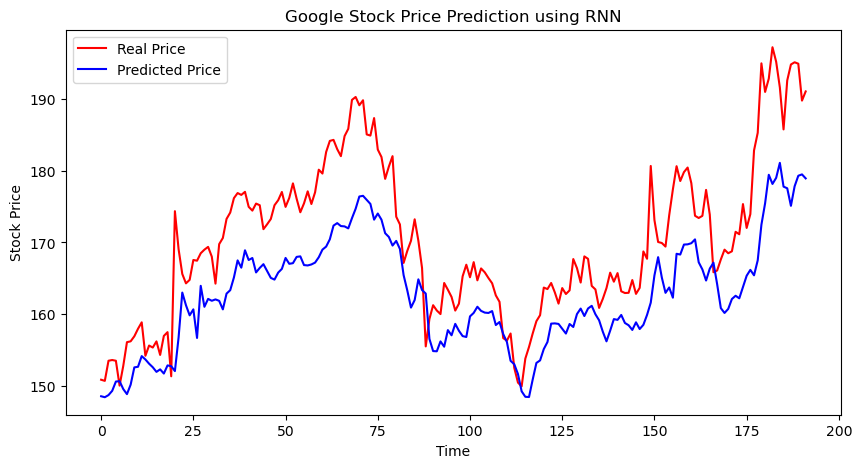

In [29]:
# ====================================================
# STEP 11: VISUALIZE RESULTS
# ====================================================

# Create graph window
plt.figure(figsize=(10, 5))

# Plot actual stock prices (RED line)
plt.plot(real, color='red', label='Real Price')

# Plot predicted stock prices (BLUE line)
plt.plot(predicted, color='blue', label='Predicted Price')

# Add title and labels
plt.title("Google Stock Price Prediction using RNN")
plt.xlabel("Time")          # X-axis → days/time
plt.ylabel("Stock Price")   # Y-axis → price

# Show legend (label names)
plt.legend()

# Display graph
plt.show()
